# Keras RGBD semantic segmentation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data augumentation

In [ ]:
OBJ = 'class1' # object to train
GDRIVE = '/content/drive/MyDrive/seg-master'

# set google drive path
import sys
ROOT_PATH = GDRIVE
sys.path.append(ROOT_PATH)

from data import *
# set the number of train images and labels
num_images = 106

# set parameters for data expansion
aug_args = dict(rotation_range = 0, #rotation
                width_shift_range = 0.05, #width shift
                height_shift_range = 0.05, #height shift
                shear_range = 0, #shear
                zoom_range = 0, #zoom
                horizontal_flip = True, #horizontal flip
                fill_mode='nearest')
# data expansion from train images and labels
generator = generate_train(num_images,
                           GDRIVE + '/data/' + OBJ + '/train',
                           'images',
                           'labels',
                           aug_args,
                           save_dir = GDRIVE + '/data/' + OBJ + '/train/aug',
                           target_size = (424,424))

# create (num_images*num_repeat) images and labels
num_repeat = 9 # repeat
for i,batch in enumerate(generator):
    if(i >= num_repeat):
        break

Found 106 images belonging to 1 classes.
Found 106 images belonging to 1 classes.


##Prepare images and labels as numpy array

In [ ]:
OBJ = 'class1' # object to train
GDRIVE = '/content/drive/MyDrive/seg-master'

# set google drive path
import sys
ROOT_PATH = GDRIVE
sys.path.append(ROOT_PATH)
# from model import
from data import *

# create numpy array and save to numpy file
imgs_train,imgs_label_train = generate_numpy(GDRIVE + '/data/' + OBJ + '/train/aug/', GDRIVE + '/data/' + OBJ + '/train/aug/')
np.save(GDRIVE + '/data/' + OBJ + '/train/images/imgs_train.npy', imgs_train)
np.save(GDRIVE + '/data/' + OBJ + '/train/labels/imgs_label_train.npy', imgs_label_train)
# check numpy array shape
print(np.shape(imgs_train))
print(np.shape(imgs_label_train))


(1060, 424, 424, 4)
(1060, 424, 424, 1)


## Training

In [ ]:
OBJ = 'class1'
VERSION = '_v08' # set version of the model
GDRIVE = '/content/drive/MyDrive/seg-master' # Google colab

import matplotlib.pyplot as plt
import sys
ROOT_PATH = GDRIVE
sys.path.append(ROOT_PATH)

import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler
from model import * # u-net model
from data import *

# set model
model = unet(input_size = (424, 424, 4)) # select input size

# make a check point
checkpoint = ModelCheckpoint(GDRIVE + '/data/' + OBJ + '/model/unet_' + OBJ + VERSION + '.h5', # check point
                     monitor = 'val_loss', # validation loss
                     verbose = 1, # result
                     save_best_only = True)


# set early stopping not to overtrain
earlystopping = EarlyStopping(monitor = 'val_loss',
                   patience = 5, # stop if the performance does not improve for 50 epochs
                   restore_best_weights = True)

# load numpy files of images and labels
imgs_train = np.load(GDRIVE + '/data/' + OBJ + '/train/images/imgs_train.npy')
imgs_label_train = np.load(GDRIVE + '/data/' + OBJ + '/train/labels/imgs_label_train.npy')

# train the model
history = model.fit(imgs_train,
                    imgs_label_train,
                    batch_size = 10,
                    epochs = 30,
                    verbose = 1,
                    validation_split = 0.2,
                    shuffle = True,
                    callbacks = [checkpoint, earlystopping])

# Plot training & validation DICE coefficient values
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title('Dice coefficient')
plt.ylabel('dice_coef')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation BCE-DICE loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'], loc='upper left')
plt.show()

Epoch 1/30
85/85 [==============================] - ETA: 0s - loss: 0.6372 - dice_coef: 0.3875
Epoch 1: val_loss improved from inf to 0.38820, saving model to /content/drive/MyDrive/seg-master/data/class1/model/unet_class1_v08.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


85/85 [==============================] - 281s 3s/step - loss: 0.6372 - dice_coef: 0.3875 - val_loss: 0.3882 - val_dice_coef: 0.6149
Epoch 2/30
85/85 [==============================] - ETA: 0s - loss: 0.3681 - dice_coef: 0.6349
Epoch 2: val_loss improved from 0.38820 to 0.35440, saving model to /content/drive/MyDrive/seg-master/data/class1/model/unet_class1_v08.h5
85/85 [==============================] - 175s 2s/step - loss: 0.3681 - dice_coef: 0.6349 - val_loss: 0.3544 - val_dice_coef: 0.6489
Epoch 3/30
85/85 [==============================] - ETA: 0s - loss: 0.3444 - dice_coef: 0.6584
Epoch 3: val_loss improved from 0.35440 to 0.32751, saving model to /content/drive/MyDrive/seg-master/data/class1/model/unet_class1_v08.h5
85/85 [==============================] - 175s 2s/step - loss: 0.3444 - dice_coef: 0.6584 - val_loss: 0.3275 - val_dice_coef: 0.6753
Epoch 4/30
85/85 [==============================] - ETA: 0s - loss: 0.3234 - dice_coef: 0.6790
Epoch 4: val_loss improved from 0.32751 t

## Inference

10/10 [==============================] - 10s 734ms/step


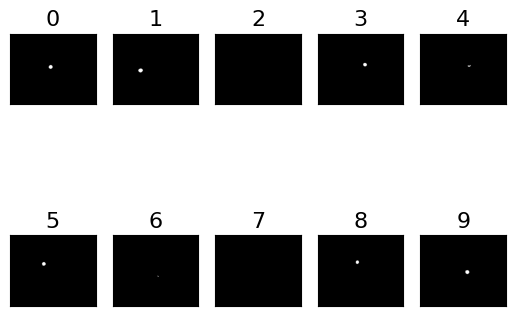

In [ ]:
VERSION = '_v08'
OBJ = 'class1'
num_test = 10 # number of images
GDRIVE = '/content/drive/MyDrive/seg-master' # Google colab

import sys
ROOT_PATH = GDRIVE
sys.path.append(ROOT_PATH)

import os
from model import *
from data import *
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# load the trained model
from tensorflow import keras
model = keras.models.load_model(GDRIVE + '/data/' + OBJ + '/model/unet_' + OBJ + VERSION + '.h5', custom_objects={'bce_dice_loss': bce_dice_loss, 'dice_coef': dice_coef})

# prepare test images
test = generate_test(GDRIVE + '/data/' + OBJ + '/test', num_image = num_test, image_size = (424, 424))

# prediction
results = model.predict(test, steps = num_test, verbose = 1)

# post process results and save them to _predict.png
for i,item in enumerate(results):
        img = item[:,:,0]
        img = (img > 0.5).astype(np.uint8)
        img = (img * 255)
        img = cv.resize(img, (512, 424))
        cv.imwrite(os.path.join(GDRIVE + '/data/' + OBJ + '/test_new',"predict_%d.png"%i), img)

# check every test result
fig, ax = plt.subplots(2, 5)
for i in range(10):
  img = cv.imread(GDRIVE + '/data/' + OBJ + '/testnew/' + 'predict_%d.png'%i)
  r = i//5
  c = i%5
  ax[r,c].set_title(i, fontsize = 16)
  ax[r,c].axes.xaxis.set_visible(False)
  ax[r,c].axes.yaxis.set_visible(False)
  ax[r,c].imshow(img)

##Save model s savedmodel format


In [1]:
VERSION = '_v07'
OBJ = 'class1'
GDRIVE = '/content/drive/MyDrive/seg-master' # Google colab

import tensorflow as tf
import sys
ROOT_PATH = GDRIVE
sys.path.append(ROOT_PATH)
from tensorflow.keras.models import load_model
from model import *
from data import *

# load .h5 model
model = load_model(GDRIVE + '/data/' + OBJ + '/model/unet_' + OBJ + VERSION + '.h5', custom_objects={'bce_dice_loss': bce_dice_loss, 'dice_coef': dice_coef})

# save as savedmodel format
from tensorflow.keras.models import save_model
model.save(GDRIVE + '/data/' + OBJ + '/model/unet_test')